# Projet : IA for HumanForYou

L'idée de ce projet est de faire suite à la validation éthique (voir livrable éthique).
Nous allons donc mettre en place un pipeline, comprenant plusieurs étapes :
- Création de 3 jeux de données :
***Courbe d'apprentissage, données aléatoires***
    - Avec un jeu d'apprentissage (60%)
    - Avec un jeu de validation (20%)
    - Avec un jeu de test (20%)
- Pré-traitement :
    - Valeurs manquantes, aberrantes, éronnées (erreur de type par exemple)
    - Standardisation (normalisation)
- Choix du modèle et des caractéristiques :
    - Modèle 1
    - Modèle 2
    - Modèle 3
- Apprentissage sur jeu d'apprentissage
- Validation sur jeu de validation
- Evaluation finale sur jeu de test


In [1]:
# Variable to choose whether to drop missing data or replace it with the median or mean
dropData = False 

## Installation et Import

In [ ]:
%pip install --upgrade pip
%pip install pandas
%pip install Matplotlib
%pip install SNS seaborn
%pip install numpy
%pip install scikit-learn
%pip install missingno

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import tarfile
import os
from sklearn.preprocessing import LabelEncoder,StandardScaler
import missingno as msno
import scipy.stats as stats

## Import des données

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt

# Configuring display settings
plt.rcParams['figure.figsize'] = (12, 9)
sns.set_theme()
sns.set_context('talk')
np.set_printoptions(threshold=20, precision=2, suppress=True)
pd.set_option('display.max_rows', 30)
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 2)
pd.set_option('display.float_format', '{:.2f}'.format)

# Extract all .csv files
general_data_file_path = '../Data/general_data.csv'
employee_survey_data_file_path = '../Data/employee_survey_data.csv'
manager_survey_data_file_path = '../Data/manager_survey_data.csv'
in_data_file_path = '../Data/in_time.csv'
out_data_file_path = '../Data/out_time.csv'

# Load the dataset
general_data = pd.read_csv(general_data_file_path)
employee_survey_data = pd.read_csv(employee_survey_data_file_path)
manager_survey_data = pd.read_csv(manager_survey_data_file_path)

# Handling malformatted CSV files for in_time and out_time
in_data = pd.read_csv(in_data_file_path, sep=",", engine="python", quoting=3)
out_data = pd.read_csv(out_data_file_path, sep=",", engine="python", quoting=3)

in_data.columns = (in_data.columns.str.strip().str.replace('"', '', regex=False))
out_data.columns = (out_data.columns.str.strip().str.replace('"', '', regex=False))

for col in in_data.columns:
    in_data[col] = in_data[col].astype(str).str.strip().str.replace('"', '', regex=False)

for col in out_data.columns:
    out_data[col] = out_data[col].astype(str).str.strip().str.replace('"', '', regex=False)

# Reshape in_time and out_time data from wide to long format to facilitate analysis
in_data = in_data.melt(id_vars="EmployeeID", var_name="date", value_name="in_time")
out_data = out_data.melt(id_vars="EmployeeID", var_name="date", value_name="out_time")

# Remove rows with missing or invalid time entries
in_data = in_data[in_data["in_time"].notna() &(in_data["in_time"] != "NA") &(in_data["in_time"] != "nan")]
out_data = out_data[out_data["out_time"].notna() &(out_data["out_time"] != "NA") &(out_data["out_time"] != "nan")]

# Applying types to data
in_data["EmployeeID"] = pd.to_numeric(in_data["EmployeeID"], errors="coerce")
out_data["EmployeeID"] = pd.to_numeric(out_data["EmployeeID"], errors="coerce")

in_data["in_time"] = pd.to_datetime(in_data["in_time"], errors="coerce")
out_data["out_time"] = pd.to_datetime(out_data["out_time"], errors="coerce")

# Merge In and Out data on EmployeeID and date to calculate time-based features
time_data = in_data.merge(out_data, on=["EmployeeID", "date"], how="inner")

# Features arrival, departure and worked hours in float format (hours)
time_data["arrival_float"] = (time_data["in_time"].dt.hour + time_data["in_time"].dt.minute / 60 + time_data["in_time"].dt.second / 3600)
time_data["departure_float"] = (time_data["out_time"].dt.hour + time_data["out_time"].dt.minute / 60 + time_data["out_time"].dt.second / 3600)
time_data["worked_float"] = ((time_data["out_time"] - time_data["in_time"]).dt.total_seconds() / 3600)

# Average arrival, departure and worked hours per employee
employee_time_features_data = time_data.groupby("EmployeeID", as_index=False).agg(AverageArrival=("arrival_float", "mean"),AverageDeparture=("departure_float", "mean"),AverageWorkedHours=("worked_float", "mean"),)

# Check if the data is loaded correctly
print("----------------------------------------------------------------------------")
print("General Data Head:")
print(general_data.head())
print("----------------------------------------------------------------------------")
print("Employee Survey Data Head:")
print(employee_survey_data.head())
print("----------------------------------------------------------------------------")
print("Manager Survey Data Head:")
print(manager_survey_data.head())
print("----------------------------------------------------------------------------")
print("Employee time features Data Head:")
print(employee_time_features_data.head())
print("----------------------------------------------------------------------------")

## Selection des données

Dans un soucis ethique et morale, nous avons décidé de ne pas selectionner certaines données, afin d'eviter le plus de biais possible lors de l'analyse

In [4]:
# Drop collumns with unethical data for analysis, such as Age, Gender and MaritalStatus which can lead to bias in the analysis and may not be relevant for the analysis of employee attrition.
general_data = general_data.drop(columns=['Age', 'Gender', 'MaritalStatus'])

Nous allons également filtrer les données qui n'influenceront pas l'analyse, comme le temps de travail qui est de 8h pour tout les employées et le fait d'etre majeur par exemple

In [ ]:
# Drop collumns with non interresting values for analysis, such as EmployeeCount, Over18 and StandardHours which are the same for all employees and do not provide any useful information for analysis.
general_data = general_data.drop(columns=['EmployeeCount', 'Over18', 'StandardHours'])

## Filtrage des données

Maintenant que nous avons filtré les données, nous allons vérifier les valeurs manquantes, aberrantes, éronnées, cohérentes et dupliquées.

In [ ]:
print("----------------------------------------------------------------------------")
print("General Data Information:")
print(general_data.info())
print("----------------------------------------------------------------------------")
print("General Data Description:")
print(general_data.describe())
print("----------------------------------------------------------------------------")
print("General Data Missing Values:")
print(general_data.isnull().sum())
print("----------------------------------------------------------------------------")
print()

print("----------------------------------------------------------------------------")
print("Employee Survey Data Information:")
print(employee_survey_data.info())
print("----------------------------------------------------------------------------")
print("Employee Survey Data Description:")
print(employee_survey_data.describe())
print("----------------------------------------------------------------------------")
print("Employee Survey Data Missing Values:")
print(employee_survey_data.isnull().sum())
print("----------------------------------------------------------------------------")
print()

print("----------------------------------------------------------------------------")
print("Manager Survey Data Information:")
print(manager_survey_data.info())
print("----------------------------------------------------------------------------")
print("Manager Survey Data Description:")
print(manager_survey_data.describe())
print("----------------------------------------------------------------------------")
print("Manager Survey Data Missing Values:")
print(manager_survey_data.isnull().sum())
print("----------------------------------------------------------------------------")
print()

print("----------------------------------------------------------------------------")
print("Employee Time Features Data Information:")
print(employee_time_features_data.info())
print("----------------------------------------------------------------------------")
print("Employee Time Features Data Description:")
print(employee_time_features_data.describe())
print("----------------------------------------------------------------------------")
print("Employee Time Features Data Missing Values:")
print(employee_time_features_data.isnull().sum())
print("----------------------------------------------------------------------------")
print()

### Valeurs manquantes

In [ ]:
# CHECKING THE IMPACT OF MISSING VALUES ON THE MEAN OF THE "TotalWorkingYears" COLUMN

# Only for testing purposes, to see the impact of missing values on the mean of the "TotalWorkingYears" column. We will drop the missing values, replace them with the median and replace them with a constant value (50) to see the difference in the mean. """
# c = general_data["TotalWorkingYears"].dropna()
# a = general_data["TotalWorkingYears"].fillna(general_data["TotalWorkingYears"].median())
# b = general_data["TotalWorkingYears"].fillna(50)

# print("Mean after dropping missing values:", c.mean())
# print("Mean after replacing with median:", a.mean())
# print("Mean after replacing with 50:", b.mean())


In [ ]:
import matplotlib.pyplot as plt
import missingno as msno

print("----------------------------------------------------------------------------")
print(general_data["NumCompaniesWorked"].value_counts())
print("----------------------------------------------------------------------------")
print(general_data["TotalWorkingYears"].value_counts())
print("----------------------------------------------------------------------------")
print()
print("----------------------------------------------------------------------------")
print(employee_survey_data["EnvironmentSatisfaction"].value_counts())
print("----------------------------------------------------------------------------")
print(employee_survey_data["JobSatisfaction"].value_counts())
print("----------------------------------------------------------------------------")
print(employee_survey_data["WorkLifeBalance"].value_counts())
print("----------------------------------------------------------------------------")

# Visualize missing data
msno.matrix(general_data)
plt.title("Missing Values in General Survey Data")
plt.show()

general_data_numerical_columns = general_data.select_dtypes(include=['float64', 'int64']).columns
general_data_categorical_columns = general_data.select_dtypes(include=['object']).columns

# Fill missing values in general_data with the mode
if dropData:
    general_data = general_data.dropna()
else:
    general_data[general_data_numerical_columns] = general_data[general_data_numerical_columns].fillna(general_data[general_data_numerical_columns].median())
    general_data[general_data_categorical_columns] = general_data[general_data_categorical_columns].fillna(general_data[general_data_categorical_columns].mode().iloc[0])

print("----------------------------------------------------------------------------")
print("General Data Missing Values:")
print(general_data.isnull().sum())
print("----------------------------------------------------------------------------")
print()

msno.matrix(employee_survey_data)
plt.title("Missing Values in Employee Survey Data")
plt.show()

employee_survey_data_numerical_columns = employee_survey_data.select_dtypes(include=['float64', 'int64']).columns
employee_survey_data_categorical_columns = employee_survey_data.select_dtypes(include=['object']).columns

# Fill missing values in employee_survey_data with the mode
if dropData:
    employee_survey_data = employee_survey_data.dropna()
else:
    employee_survey_data[employee_survey_data_numerical_columns] = employee_survey_data[employee_survey_data_numerical_columns].fillna(employee_survey_data[employee_survey_data_numerical_columns].median())

print("----------------------------------------------------------------------------")
print("Employee Survey Data Missing Values:")
print(employee_survey_data.isnull().sum())
print("----------------------------------------------------------------------------")

# No missing value in manager_survey_data and employee_time_features_data so we don't need to fill them

print("Final verification of missing values after filling them:")
# Check for duplicates in general_data and employee_survey_data 
print("----------------------------------------------------------------------------")
print("General Data Duplicates:")
print(general_data.duplicated().sum())
print("----------------------------------------------------------------------------")
print("Employee Survey Data Duplicates:")
print(employee_survey_data.duplicated().sum())
print("----------------------------------------------------------------------------")
print()

## Mise en relation des CSV

Maintenant que nous n'avons que les valeurs que nous souhaitons garder dans les CSV, on peut les joindre

In [ ]:
import pandas as pd

print("Nombre de lignes et de colonnes dans general_data:", general_data.shape)
print("Nombre de lignes et de colonnes dans employee_survey_data:", employee_survey_data.shape)
print("Nombre de lignes et de colonnes dans manager_survey_data:", manager_survey_data.shape)
print("Nombre de lignes et de colonnes dans employee_time_features_data:", employee_time_features_data.shape)

# Join general_data, employee_survey_data and manager_survey_data on EmployeeID
data = pd.merge(general_data, employee_survey_data, on='EmployeeID', how='inner')
data = pd.merge(data, manager_survey_data, on='EmployeeID', how='inner')
data = pd.merge(data, employee_time_features_data, on='EmployeeID', how='inner')

print("Nombre de lignes et de colonnes après la jointure:", data.shape)

In [10]:
education_map = {
    1: 'Avant College',
    2: 'College',
    3: 'Bachelor',
    4: 'Master',
    5: 'PhD'
}

job_map = {
    1: 'Niveau 1',
    2: 'Niveau 2',
    3: 'Niveau 3',
    4: 'Niveau 4',
    5: 'Niveau 5'
}

satisfaction_map = {
    1: 'Faible',
    2: 'Moyen',
    3: 'Elevé',
    4: 'Très élevé'
}

balance_map = {
    1: 'Mauvais',
    2: 'Satisfaisant',
    3: 'Très satisfaisant',
    4: 'Excellent'
}

involvement_map = {
    1: 'Faible',
    2: 'Moyenne',
    3: 'Importante',
    4: 'Très importante'
}

performance_map = {
    1: 'Faible',
    2: 'Bon',
    3: 'Excellent',
    4: 'Au delà des attentes'
}

data['JobLevel'] = data['JobLevel'].map(job_map)
data['Education'] = data['Education'].map(education_map)
data['EnvironmentSatisfaction'] = data['EnvironmentSatisfaction'].map(satisfaction_map)
data['JobSatisfaction'] = data['JobSatisfaction'].map(satisfaction_map)
data['WorkLifeBalance'] = data['WorkLifeBalance'].map(balance_map)
data['JobInvolvement'] = data['JobInvolvement'].map(involvement_map)
data['PerformanceRating'] = data['PerformanceRating'].map(performance_map)

category_orders = {
    'JobLevel': [job_map[i] for i in sorted(job_map)],
    'Education': [education_map[i] for i in sorted(education_map)],
    'EnvironmentSatisfaction': [satisfaction_map[i] for i in sorted(satisfaction_map)],
    'JobSatisfaction': [satisfaction_map[i] for i in sorted(satisfaction_map)],
    'WorkLifeBalance': [balance_map[i] for i in sorted(balance_map)],
    'JobInvolvement': [involvement_map[i] for i in sorted(involvement_map)],
    'PerformanceRating': [performance_map[i] for i in sorted(performance_map)]
}

data.info()

data_numerical_columns = data.select_dtypes(include=['float64', 'int64']).columns
data_categorical_columns = data.select_dtypes(include=['object', 'str']).columns

data_numerical_columns = data_numerical_columns.drop('EmployeeID', errors='ignore')  # Drop EmployeeID from numerical columns as it's an identifier

#~Univariate analysis for numerical features
for column in data_numerical_columns:
    plt.figure(figsize=(10, 4))
    sns.histplot(data[column], kde=True)
    plt.title(f'Distribution of {column}')
    plt.show()

# Univariate analysis for categorical features
for column in data_categorical_columns:
    plt.figure(figsize=(10, 4))
    sns.countplot(x=data[column], order=category_orders.get(column, None))
    plt.title(f'Distribution of {column}')
    plt.xticks(rotation=45)
    plt.show()


## Visualisation des données

In [ ]:
# Scatter plots for pairs of numerical features
sns.pairplot(data[data_numerical_columns])
plt.show()

In [ ]:
# Correlation heatmap for numerical features
plt.figure(figsize=(12, 8))
sns.heatmap(data[data_numerical_columns].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(12, 8))
plt.hexbin(data['AverageArrival'], data['AverageDeparture'], C=data['AverageWorkedHours'], gridsize=50, cmap='YlOrRd', reduce_C_function=np.mean)
plt.colorbar(label='Mean Worked Hours')
plt.xlabel('Average Arrival')
plt.ylabel('Average Departure')
plt.title('Hexbin Map of Worked Hours')
plt.show()

plt.hexbin(data['TotalWorkingYears'], data['YearsAtCompany'], C=data['YearsWithCurrManager'], gridsize=50, cmap='YlOrRd', reduce_C_function=np.mean)
plt.colorbar(label='Mean Years with Current Manager')
plt.xlabel('Total Working Years')
plt.ylabel('Years at Company')
plt.title('Hexbin Map of Years with Current Manager')
plt.show()

plt.hexbin(data['YearsAtCompany'], data['YearsWithCurrManager'], C=data['YearsSinceLastPromotion'], gridsize=50, cmap='YlOrRd', reduce_C_function=np.mean)
plt.colorbar(label='Mean Years Since Last Promotion')
plt.xlabel('Total Working Years')
plt.ylabel('Years at Company')
plt.title('Hexbin Map of Years with Current Manager')
plt.show()

## Box plot (valeurs abérrantes)

In [ ]:
for col in data_numerical_columns:
	plt.title("AVANT "+col)
	sns.boxplot(data[col])
	plt.show()

In [ ]:
for col in data_numerical_columns:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    #data = data[(data[col] >= lower) & (data[col] <= upper)]
    data[col] = data[col].clip(lower, upper)
    data.info()


<class 'pandas.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Attrition                4410 non-null   str    
 1   BusinessTravel           4410 non-null   str    
 2   Department               4410 non-null   str    
 3   DistanceFromHome         4410 non-null   int64  
 4   Education                4410 non-null   str    
 5   EducationField           4410 non-null   str    
 6   EmployeeID               4410 non-null   int64  
 7   JobLevel                 4410 non-null   str    
 8   JobRole                  4410 non-null   str    
 9   MonthlyIncome            4410 non-null   int64  
 10  NumCompaniesWorked       4410 non-null   float64
 11  PercentSalaryHike        4410 non-null   int64  
 12  StockOptionLevel         4410 non-null   int64  
 13  TotalWorkingYears        4410 non-null   float64
 14  TrainingTimesLastYear    4410 non-n

In [ ]:
for col in data_numerical_columns:
	plt.title("APRES "+col)
	sns.boxplot(data[col])
	plt.show()

#### Création de 3 jeux de données

##### One-hot-encoding pour pouvoir standardisé et entrainer les modèles

In [31]:
data = pd.get_dummies(data)
data = data.drop("Attrition_No", axis=1)

In [32]:
from sklearn.model_selection import train_test_split

X = data.drop("Attrition_Yes", axis=1)
y = data["Attrition_Yes"]

X_train, X_temp, y_train, y_temp = train_test_split(
	X, y, test_size= 0.4, random_state=42
)
xTrainColumns = X_train.columns

X_val, X_test, y_val, y_test = train_test_split(
	X_temp, y_temp, test_size= 0.5, random_state=42
)


### Standardisation

In [33]:
# Normalisation des colonnes numériques
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)


housing_num_scaled = pd.DataFrame(X_train, columns=xTrainColumns)

# Vérification de la normalisation
housing_num_scaled.head()

,DistanceFromHome,EmployeeID,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager,AverageArrival,AverageDeparture,AverageWorkedHours,BusinessTravel_Non-Travel,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Human Resources,Department_Research & Development,Department_Sales,Education_Avant College,Education_Bachelor,Education_College,Education_Master,Education_PhD,EducationField_Human Resources,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,JobLevel_Niveau 1,JobLevel_Niveau 2,JobLevel_Niveau 3,JobLevel_Niveau 4,JobLevel_Niveau 5,JobRole_Healthcare Representative,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,EnvironmentSatisfaction_Elevé,EnvironmentSatisfaction_Faible,EnvironmentSatisfaction_Moyen,EnvironmentSatisfaction_Très élevé,JobSatisfaction_Elevé,JobSatisfaction_Faible,JobSatisfaction_Moyen,JobSatisfaction_Très élevé,WorkLifeBalance_Excellent,WorkLifeBalance_Mauvais,WorkLifeBalance_Satisfaisant,WorkLifeBalance_Très satisfaisant,JobInvolvement_Faible,JobInvolvement_Importante,JobInvolvement_Moyenne,JobInvolvement_Très importante,PerformanceRating_Au delà des attentes,PerformanceRating_Excellent
0,-0.26,-0.20,-0.14,1.75,-0.89,-0.98,-0.29,0.29,-1.11,-0.77,-1.16,-0.71,-1.23,-1.22,-0.35,-0.49,0.66,-0.20,0.73,-0.67,-0.36,-0.79,2.07,-0.62,-0.19,-0.13,1.17,-0.35,-0.67,-0.24,-0.31,1.29,-0.74,-0.42,-0.28,-0.22,-0.30,-0.20,-0.47,-0.27,-0.33,-0.25,2.01,-0.53,-0.24,-0.66,2.08,-0.50,-0.66,1.51,-0.49,-0.49,-0.67,-0.33,-0.23,1.81,-1.26,-0.24,0.85,-0.61,-0.32,-0.43,0.43
1,-0.63,-1.38,-0.15,-1.09,-0.89,0.29,-0.29,-2.09,0.28,-0.36,0.83,-1.86,1.80,1.82,-0.35,-0.49,0.66,-0.20,0.73,-0.67,-0.36,1.27,-0.48,-0.62,-0.19,-0.13,1.17,-0.35,-0.67,-0.24,-0.31,-0.77,-0.74,-0.42,-0.28,4.53,3.29,-0.20,-0.47,-0.27,-0.33,-0.25,-0.50,-0.53,-0.24,-0.66,-0.48,2.00,-0.66,-0.66,2.04,-0.49,-0.67,-0.33,-0.23,1.81,-1.26,-0.24,-1.18,1.64,-0.32,-0.43,0.43
2,-0.26,-0.24,0.16,-0.68,-1.16,-0.98,1.19,0.29,2.26,0.04,0.83,-0.65,1.81,1.82,-0.35,2.06,-1.52,-0.20,0.73,-0.67,-0.36,-0.79,-0.48,1.60,-0.19,-0.13,1.17,-0.35,-0.67,-0.24,-0.31,-0.77,-0.74,2.36,-0.28,-0.22,-0.30,-0.20,-0.47,-0.27,-0.33,-0.25,-0.50,1.88,-0.24,1.51,-0.48,-0.50,-0.66,1.51,-0.49,-0.49,-0.67,3.00,-0.23,-0.55,-1.26,-0.24,0.85,-0.61,-0.32,-0.43,0.43
3,-0.26,1.13,0.32,-0.68,-0.07,-0.98,-0.97,-0.67,-0.52,-0.77,-0.30,0.07,-0.95,-0.95,-0.35,2.06,-1.52,-0.20,0.73,-0.67,-0.36,1.27,-0.48,-0.62,-0.19,-0.13,-0.85,-0.35,1.49,-0.24,-0.31,-0.77,1.35,-0.42,-0.28,-0.22,-0.30,-0.20,-0.47,-0.27,-0.33,-0.25,-0.50,-0.53,4.20,-0.66,-0.48,-0.50,1.50,1.51,-0.49,-0.49,-0.67,-0.33,-0.23,-0.55,0.79,-0.24,-1.18,1.64,-0.32,-0.43,0.43
4,0.11,0.36,-0.65,-0.68,-0.34,-0.98,-0.43,0.29,0.28,0.44,-1.16,-1.19,1.35,1.37,-0.35,2.06,-1.52,-0.20,0.73,-0.67,-0.36,-0.79,2.07,-0.62,-0.19,-0.13,-0.85,-0.35,1.49,-0.24,-0.31,-0.77,1.35,-0.42,-0.28,-0.22,-0.30,-0.20,-0.47,-0.27,-0.33,-0.25,2.01,-0.53,-0.24,-0.66,-0.48,-0.50,1.50,1.51,-0.49,-0.49,-0.67,-0.33,-0.23,-0.55,0.79,-0.24,0.85,-0.61,-0.32,-0.43,0.43


### Choix du modèle

Matrice de Confusion (Régression Logistique) :
 [[715  33]
 [100  34]]
Rapport de Classification (Régression Logistique) :
               precision    recall  f1-score   support

       False       0.88      0.96      0.91       748
        True       0.51      0.25      0.34       134

    accuracy                           0.85       882
   macro avg       0.69      0.60      0.63       882
weighted avg       0.82      0.85      0.83       882

AUC-ROC (Régression Logistique) :
 0.6048068481123793


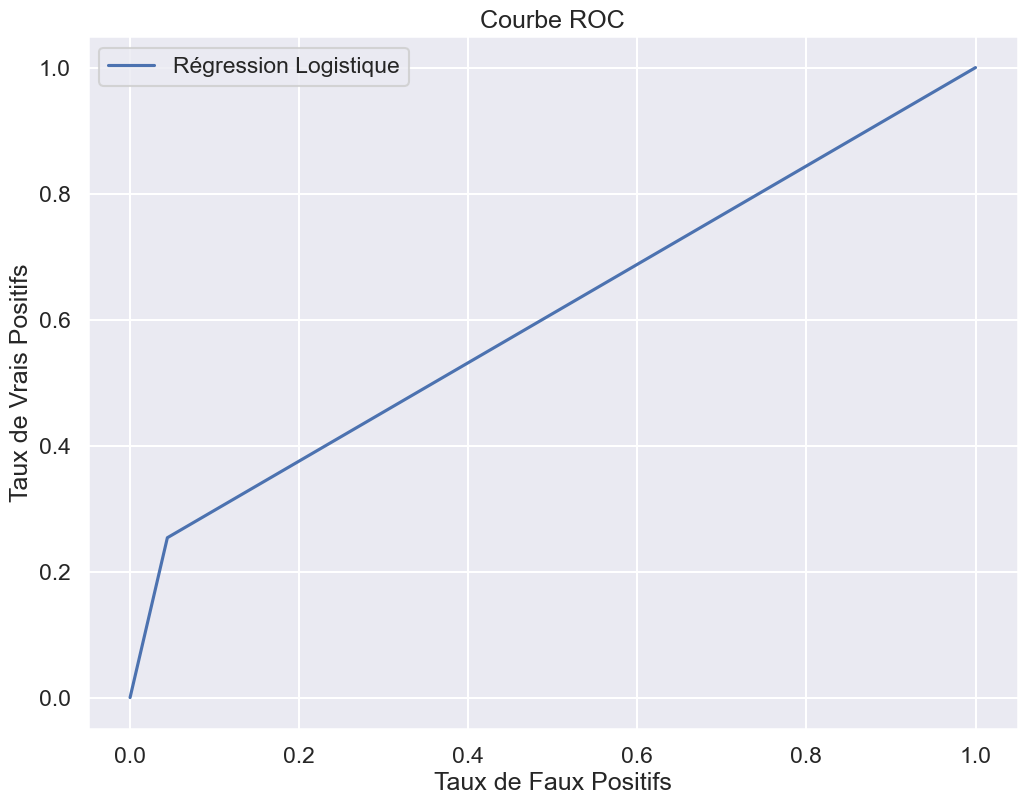

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

# Initialisation et entraînement du modèle

log_reg = LogisticRegression()
log_reg.fit(X_train,y_train)

# Prédictions
y_pred_log_reg = log_reg.predict(X_test)

# Matrice de confusion
conf_matrix_log_reg = confusion_matrix(y_test, y_pred_log_reg)
print("Matrice de Confusion (Régression Logistique) :\n", conf_matrix_log_reg)

# Rapport de classification
class_report_log_reg = classification_report(y_test, y_pred_log_reg)
print("Rapport de Classification (Régression Logistique) :\n", class_report_log_reg)

# AUC-ROC
roc_auc_log_reg = roc_auc_score(y_test, y_pred_log_reg)
print("AUC-ROC (Régression Logistique) :\n", roc_auc_log_reg)  

# Courbe ROC
fpr_log_reg, tpr_log_reg, thresholds_log_reg = roc_curve(y_test, y_pred_log_reg)
plt.plot(fpr_log_reg, tpr_log_reg, label="Régression Logistique")
plt.xlabel("Taux de Faux Positifs")
plt.ylabel("Taux de Vrais Positifs")
plt.title("Courbe ROC")
plt.legend()
plt.show()


Matrice de Confusion (Random Forest) :
 [[748   0]
 [ 36  98]]
Rapport de Classification (Random Forest) :
               precision    recall  f1-score   support

       False       0.95      1.00      0.98       748
        True       1.00      0.73      0.84       134

    accuracy                           0.96       882
   macro avg       0.98      0.87      0.91       882
weighted avg       0.96      0.96      0.96       882

AUC-ROC (Random Forest) :
 0.8656716417910448


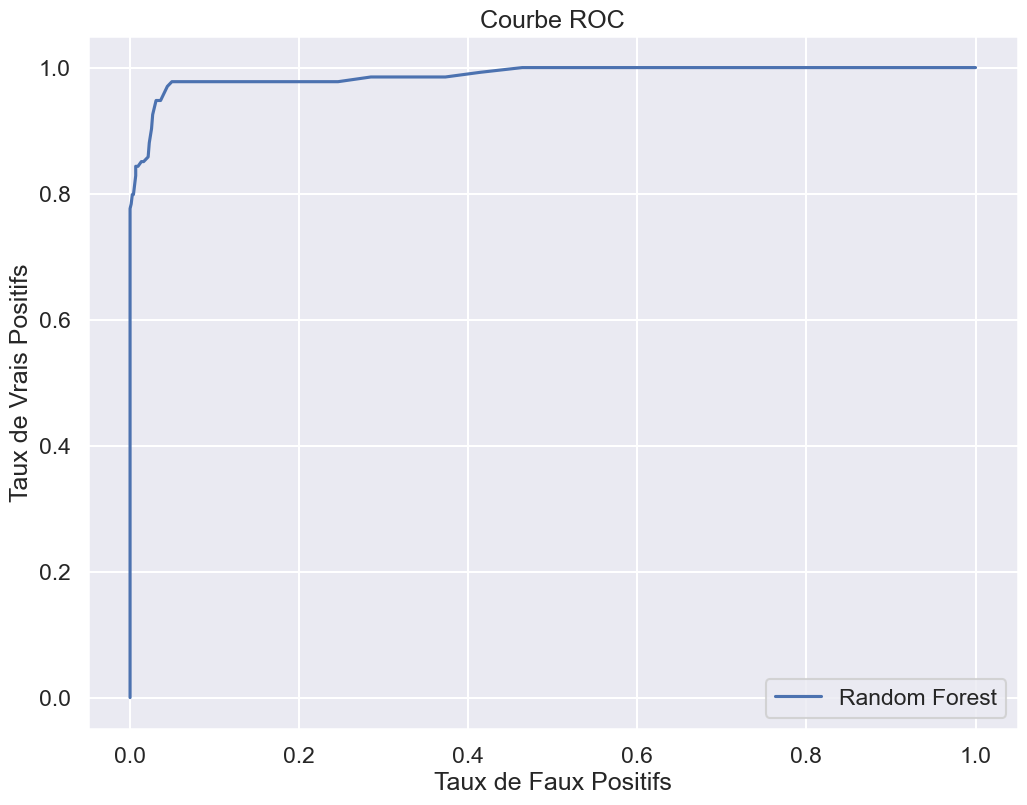

In [36]:
from sklearn.ensemble import RandomForestClassifier

# Initialisation et entraînement du modèle
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Prédictions
y_pred_rf = rf_model.predict(X_test)

# Matrice de confusion
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
print("Matrice de Confusion (Random Forest) :\n", conf_matrix_rf)

# Rapport de classification
class_report_rf = classification_report(y_test, y_pred_rf)
print("Rapport de Classification (Random Forest) :\n", class_report_rf)

# AUC-ROC
roc_auc_rf = roc_auc_score(y_test, y_pred_rf)
print("AUC-ROC (Random Forest) :\n", roc_auc_rf)

# Courbe ROC
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_proba_rf)
plt.figure()
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.xlabel("Taux de Faux Positifs")
plt.ylabel("Taux de Vrais Positifs")
plt.title("Courbe ROC")
plt.legend()
plt.show()
